# Grupo - 05
## Angel Castellanos 21700
## Diego Morales 21146

# Carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, acf
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('deep')

In [2]:
df = pd.read_csv('viajes_ya.csv', parse_dates=['week'])
df = df.sort_values('week').reset_index(drop=True)

In [3]:
CANALES = ['search_spend', 'social_spend', 'tv_spend', 'display_spend']
NOMBRES = {'search_spend': 'Motores de búsqueda',
           'social_spend': 'Redes sociales',
           'tv_spend': 'Televisión',
           'display_spend': 'Exteriores'}

# Variables derivadas de calendario
df['year']  = df['week'].dt.year
df['month'] = df['week'].dt.month
df['woy']   = df['week'].dt.isocalendar().week.astype(int)
df['t']     = np.arange(len(df))          # tendencia
df['total_spend'] = df[CANALES].sum(axis=1)

print(f"Periodo: {df.week.min().date()} a {df.week.max().date()}  ({len(df)} semanas)")
print(f"Nulos: {df.isna().sum().sum()} | Semanas duplicadas: {df.week.duplicated().sum()}")
df.head()

Periodo: 2023-01-01 a 2025-12-21  (156 semanas)
Nulos: 0 | Semanas duplicadas: 0


,week,revenue,search_spend,social_spend,tv_spend,display_spend,promotion,discount_pct,holiday,year,month,woy,t,total_spend
0,2023-01-01,"712,623.16","38,000.08","26,513.74","62,193.70","17,959.05",1,0.10,1,2023,1,52,0,"144,666.57"
1,2023-01-08,"682,516.92","32,872.22","20,731.24","91,198.93","14,477.60",0,0.00,1,2023,1,1,1,"159,279.99"
2,2023-01-15,"563,435.64","21,731.56","24,391.38",132.64,"12,717.09",0,0.00,0,2023,1,2,2,"58,972.67"
3,2023-01-22,"570,764.32","22,523.08","21,518.57","7,944.68","12,558.74",0,0.00,0,2023,1,3,3,"64,545.07"
4,2023-01-29,"603,820.13","21,082.07","14,929.85","62,613.73","7,430.73",0,0.00,0,2023,1,4,4,"106,056.38"


# Estadísticas descriptivas

In [4]:
desc = df[['revenue'] + CANALES + ['discount_pct']].describe().T
desc['CV'] = desc['std'] / desc['mean']          # coeficiente de variación
display(desc[['mean','std','min','50%','max','CV']].round(2))

print("\n--- Variables binarias ---")
print(f"Semanas con promoción: {df.promotion.sum()} ({df.promotion.mean():.1%})")
print(f"Semanas con feriado:   {df.holiday.sum()} ({df.holiday.mean():.1%})")

print("\n--- Inversión total por canal (3 años) ---")
tot = df[CANALES].sum()
resumen = pd.DataFrame({
    'Inversión total': tot,
    'Share %': (tot / tot.sum() * 100).round(1),
    'Promedio semanal': df[CANALES].mean()
})
resumen.index = [NOMBRES[c] for c in resumen.index]
display(resumen.round(2))

print(f"\nRevenue total: ${df.revenue.sum():,.0f}")
print(f"Inversión total: ${df.total_spend.sum():,.0f}")
print(f"ROAS 'naive' (revenue total / spend total): {df.revenue.sum()/df.total_spend.sum():.2f}")
print("  ^ OJO: este número NO es el ROAS real. Incluye todo el revenue base,")
print("    o sea las ventas que ocurrirían aunque no se invirtiera un centavo.")

,mean,std,min,50%,max,CV
revenue,"579,874.77","74,397.04","423,749.46","567,750.00","858,195.10",0.13
search_spend,"25,428.00","6,189.65","11,442.03","25,039.12","41,126.55",0.24
social_spend,"18,378.18","3,569.23","9,256.10","18,195.93","29,709.57",0.19
tv_spend,"16,958.27","27,148.81",132.64,"5,097.24","96,595.02",1.60
display_spend,"10,916.06","2,572.85","3,248.25","10,836.70","18,691.86",0.24
discount_pct,0.01,0.05,0.00,0.00,0.30,3.59



--- Variables binarias ---
Semanas con promoción: 13 (8.3%)
Semanas con feriado:   18 (11.5%)

--- Inversión total por canal (3 años) ---


,Inversión total,Share %,Promedio semanal
Motores de búsqueda,"3,966,768.59",35.50,"25,428.00"
Redes sociales,"2,866,996.18",25.60,"18,378.18"
Televisión,"2,645,490.21",23.70,"16,958.27"
Exteriores,"1,702,905.73",15.20,"10,916.06"



Revenue total: $90,460,464
Inversión total: $11,182,161
ROAS 'naive' (revenue total / spend total): 8.09
  ^ OJO: este número NO es el ROAS real. Incluye todo el revenue base,
    o sea las ventas que ocurrirían aunque no se invirtiera un centavo.


# Serie de tiempo del revenue

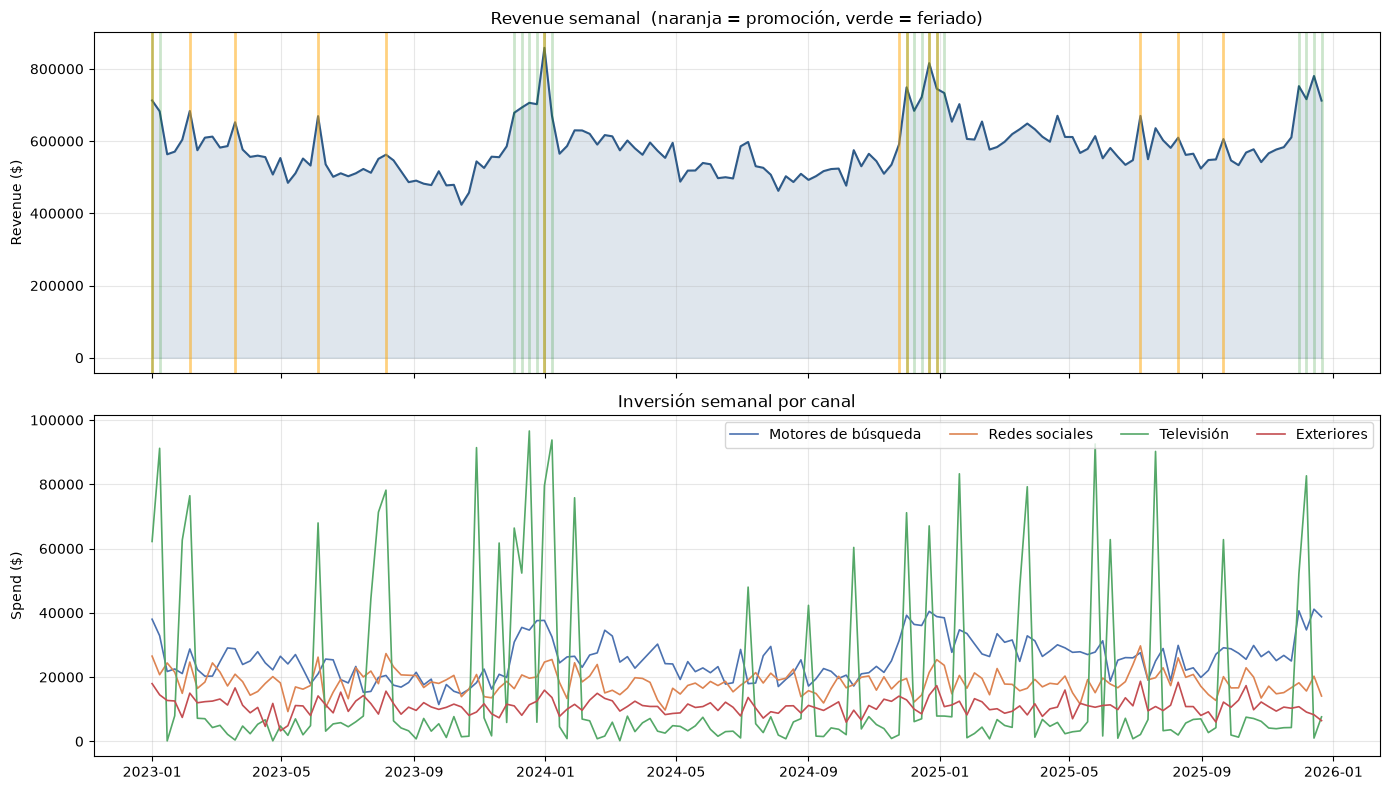

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax[0].plot(df.week, df.revenue, color='#2E5A88', lw=1.5)
ax[0].fill_between(df.week, df.revenue, alpha=0.15, color='#2E5A88')
# marcar promociones y feriados
for _, r in df[df.promotion == 1].iterrows():
    ax[0].axvline(r.week, color='orange', alpha=0.5, lw=2)
for _, r in df[df.holiday == 1].iterrows():
    ax[0].axvline(r.week, color='green', alpha=0.2, lw=2)
ax[0].set_title('Revenue semanal  (naranja = promoción, verde = feriado)')
ax[0].set_ylabel('Revenue ($)')

for c in CANALES:
    ax[1].plot(df.week, df[c], label=NOMBRES[c], lw=1.2)
ax[1].set_title('Inversión semanal por canal')
ax[1].set_ylabel('Spend ($)')
ax[1].legend(ncol=4)
plt.tight_layout(); plt.show()

# Estacionalidad

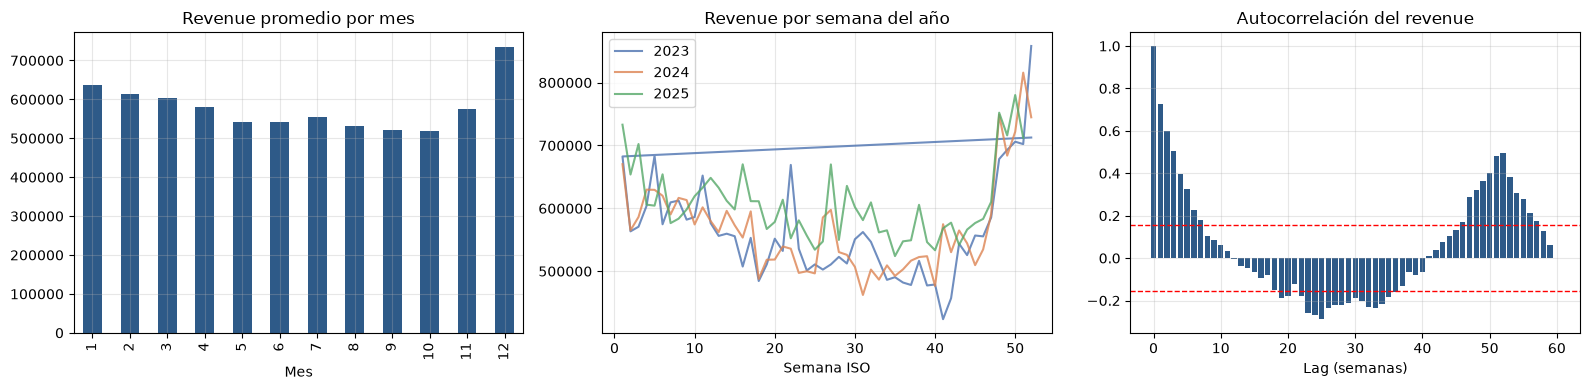

Autocorrelación lag 1:  0.740
Autocorrelación lag 52: 0.753   <- estacionalidad anual


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

df.groupby('month').revenue.mean().plot(kind='bar', ax=ax[0], color='#2E5A88')
ax[0].set_title('Revenue promedio por mes'); ax[0].set_xlabel('Mes')

for y in sorted(df.year.unique()):
    sub = df[df.year == y]
    ax[1].plot(sub.woy, sub.revenue, label=str(y), alpha=0.8)
ax[1].set_title('Revenue por semana del año'); ax[1].set_xlabel('Semana ISO'); ax[1].legend()

lags = 60
ac = acf(df.revenue, nlags=lags)
ax[2].bar(range(lags+1), ac, color='#2E5A88')
ax[2].axhline(1.96/np.sqrt(len(df)), ls='--', color='red', lw=1)
ax[2].axhline(-1.96/np.sqrt(len(df)), ls='--', color='red', lw=1)
ax[2].set_title('Autocorrelación del revenue'); ax[2].set_xlabel('Lag (semanas)')
plt.tight_layout(); plt.show()

print(f"Autocorrelación lag 1:  {df.revenue.autocorr(1):.3f}")
print(f"Autocorrelación lag 52: {df.revenue.autocorr(52):.3f}   <- estacionalidad anual")

# Correlaciones y multicolinealidad

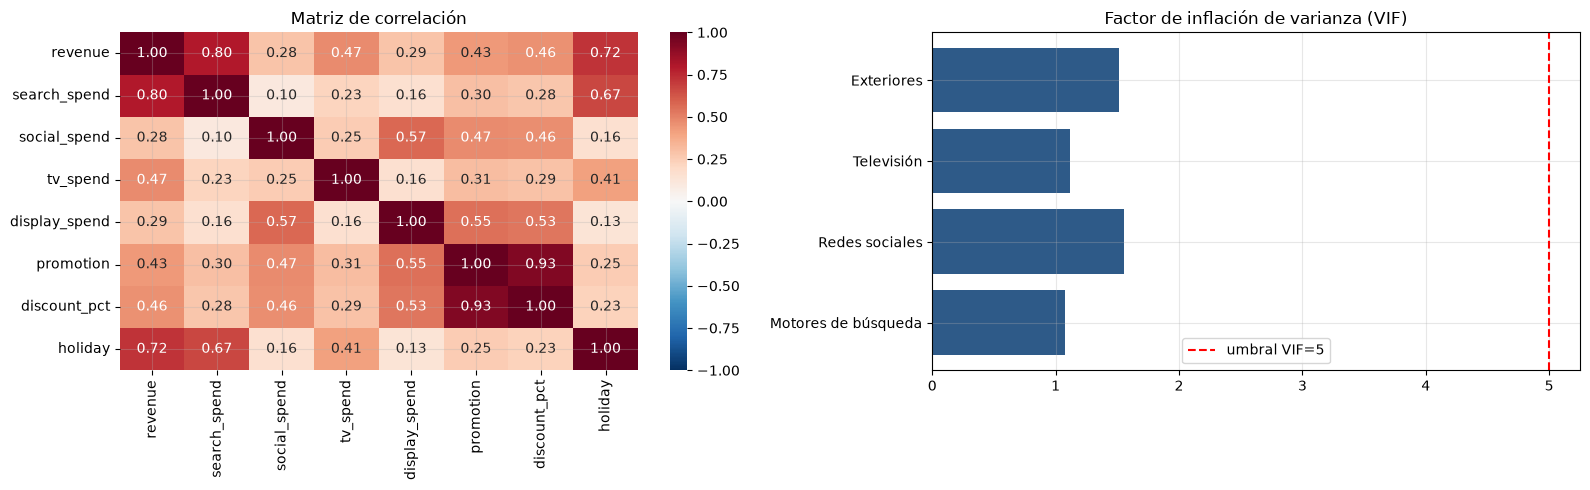

,Variable,VIF
1,search_spend,1.07
2,social_spend,1.55
3,tv_spend,1.12
4,display_spend,1.51


In [7]:
cols = ['revenue'] + CANALES + ['promotion', 'discount_pct', 'holiday']
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax[0])
ax[0].set_title('Matriz de correlación')

X = sm.add_constant(df[CANALES])
vif = pd.DataFrame({'Variable': X.columns,
                    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})
vif = vif[vif.Variable != 'const']
ax[1].barh([NOMBRES[v] for v in vif.Variable], vif.VIF, color='#2E5A88')
ax[1].axvline(5, ls='--', color='red', label='umbral VIF=5')
ax[1].set_title('Factor de inflación de varianza (VIF)'); ax[1].legend()
plt.tight_layout(); plt.show()

display(vif.round(2))

# Patrón de TV (flighting) y efecto de promo/feriado

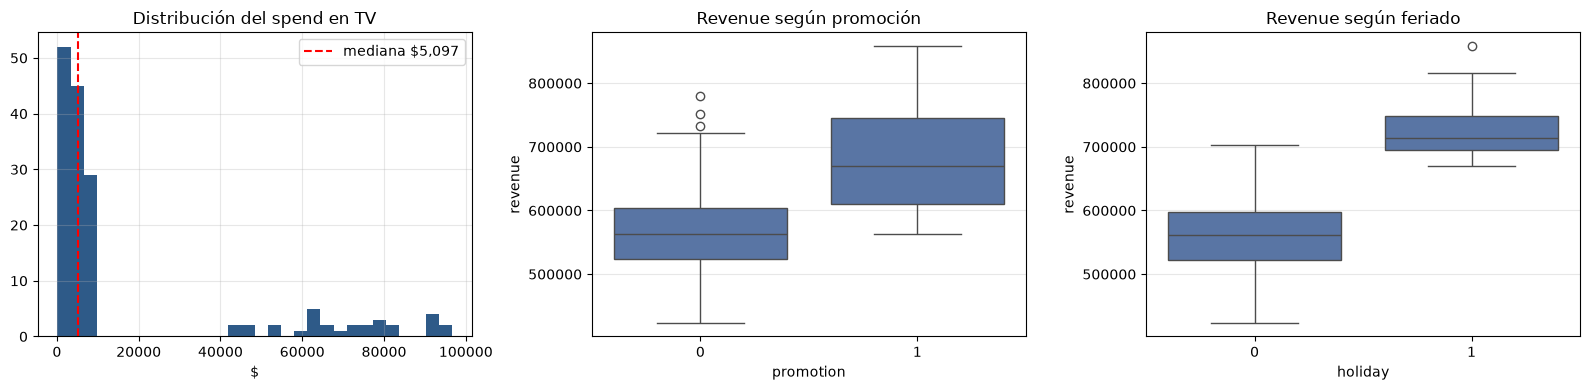

TV — percentiles:
count      156.00
mean    16,958.00
std     27,149.00
min        133.00
10%      1,239.00
25%      2,674.00
50%      5,097.00
75%      7,619.00
90%     67,514.00
max     96,595.00
Name: tv_spend, dtype: float64

Semanas con TV < $1,000: 12 de 156

Lift observado (bruto, sin controlar nada):
  Promoción: +20.4%
  Feriado:   +30.0%


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].hist(df.tv_spend, bins=30, color='#2E5A88')
ax[0].set_title('Distribución del spend en TV'); ax[0].set_xlabel('$')
ax[0].axvline(df.tv_spend.median(), color='red', ls='--', label=f'mediana ${df.tv_spend.median():,.0f}')
ax[0].legend()

sns.boxplot(data=df, x='promotion', y='revenue', ax=ax[1])
ax[1].set_title('Revenue según promoción')

sns.boxplot(data=df, x='holiday', y='revenue', ax=ax[2])
ax[2].set_title('Revenue según feriado')
plt.tight_layout(); plt.show()

print("TV — percentiles:")
print(df.tv_spend.describe(percentiles=[.1,.25,.5,.75,.9]).round(0))
print(f"\nSemanas con TV < $1,000: {(df.tv_spend<1000).sum()} de {len(df)}")
print("\nLift observado (bruto, sin controlar nada):")
print(f"  Promoción: {df[df.promotion==1].revenue.mean()/df[df.promotion==0].revenue.mean()-1:+.1%}")
print(f"  Feriado:   {df[df.holiday==1].revenue.mean()/df[df.holiday==0].revenue.mean()-1:+.1%}")

# Diagnóstico de estacionariedad

In [9]:
adf = adfuller(df.revenue)
print(f"ADF revenue: estadístico={adf[0]:.3f}, p-value={adf[1]:.4f}")
print("Serie estacionaria" if adf[1] < 0.05 else "Serie NO estacionaria")

print("\n--- Correlación de cada canal con las variables de calendario ---")
print(df[CANALES + ['holiday','promotion']].corr().loc[CANALES, ['holiday','promotion']].round(3))

ADF revenue: estadístico=-3.509, p-value=0.0078
Serie estacionaria

--- Correlación de cada canal con las variables de calendario ---
               holiday  promotion
search_spend      0.67       0.30
social_spend      0.16       0.47
tv_spend          0.41       0.31
display_spend     0.13       0.55


/tmp/ipykernel_2252/3693011671.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf = adfuller(df.revenue)


## Análisis exploratorio de la data

El conjunto de datos contiene 156 semanas continuas, desde enero de 2023 hasta diciembre de 2025, sin valores nulos ni registros duplicados. El revenue semanal promedio es de $579,875, con un coeficiente de variación de 0.13. Sin embargo, oscila entre $423,749 y $858,195, lo cual refleja un nivel base relativamente estable acompañado de incrementos concentrados en momentos específicos del calendario. Search concentra el 35.5% del presupuesto; social, el 25.6%; TV, el 23.7%; y exteriores, el 15.2%.

La forma en que se distribuye el gasto resulta más relevante que su monto total. Search, social y exteriores presentan coeficientes de variación de entre 0.19 y 0.24, lo que indica una inversión relativamente continua. En cambio, TV tiene un coeficiente de variación de 1.60 y una distribución bimodal: durante 125 semanas, la inversión fue inferior a $10,000, mientras que en aproximadamente 25 semanas se ubicó entre $45,000 y $96,595, casi sin valores intermedios. Esto demuestra que TV no escala gradualmente, sino que se activa mediante campañas puntuales. Por ello, existen pocas observaciones del canal en funcionamiento y la estimación de su efecto será menos precisa.

La estacionalidad es marcada: diciembre registra un revenue promedio de $735,470, frente a $519,088 en octubre. Además, las curvas correspondientes a las semanas ISO de los tres años presentan patrones muy similares. La función de autocorrelación (ACF) no disminuye de forma continua, sino que muestra un comportamiento ondulatorio y vuelve a elevarse hasta aproximadamente 0.5 alrededor del rezago 52, lo que evidencia un ciclo anual. La autocorrelación en el rezago 1 es de 0.740, por lo que podrían presentarse residuos correlacionados. La prueba ADF descarta la presencia de una raíz unitaria; sin embargo, esto no implica que no exista estacionalidad, sino únicamente que no es necesario diferenciar la serie para hacerla estacionaria.

El principal hallazgo es la endogeneidad en la asignación del presupuesto. Revenue y search presentan una correlación de 0.80, la más alta del conjunto. No obstante, search también se correlaciona en 0.67 con holiday, mientras que holiday se correlaciona en 0.72 con revenue. Esto indica que la temporada alta explica simultáneamente el aumento del revenue y de la inversión en búsqueda. Exteriores presenta un patrón similar, ya que se correlaciona más con promotion que con revenue. Los factores de inflación de la varianza (VIF) de los canales se encuentran por debajo de 1.6, por lo que la multicolinealidad entre medios no constituye la principal dificultad. El problema central es la posible omisión de variables relevantes, debido a que la inversión en los canales responde a la demanda esperada. Por esta misma razón, el ROAS agregado de 8.099 no representa adecuadamente el efecto de la publicidad, pues atribuye a los medios todas las ventas, incluido el revenue base que habría existido sin inversión publicitaria.

# Modelo Inicial

In [10]:
y  = df['revenue']
X1 = sm.add_constant(df[CANALES])

modelo1 = sm.OLS(y, X1).fit()
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     115.3
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           7.29e-45
Time:                        23:08:01   Log-Likelihood:                -1861.5
No. Observations:                 156   AIC:                             3733.
Df Residuals:                     151   BIC:                             3748.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          2.877e+05   1.99e+04     14.438

# Interpretación de coeficientes

In [11]:
coef = pd.DataFrame({
    'Canal': [NOMBRES[c] for c in CANALES],
    'Coeficiente': [modelo1.params[c] for c in CANALES],
    'p-value': [modelo1.pvalues[c] for c in CANALES],
    'IC 2.5%': [modelo1.conf_int().loc[c, 0] for c in CANALES],
    'IC 97.5%': [modelo1.conf_int().loc[c, 1] for c in CANALES],
    'Spend promedio': [df[c].mean() for c in CANALES],
})
coef['Contribución $'] = coef['Coeficiente'] * coef['Spend promedio']
coef['Contribución %'] = coef['Contribución $'] / y.mean() * 100
coef['Significativo'] = np.where(coef['p-value'] < 0.05, 'Sí', 'No')
display(coef.round(2))

base = modelo1.params['const']
print(f"\nIntercepto (revenue base implícito): ${base:,.0f}  =  {base/y.mean():.1%} del revenue promedio")
print(f"Contribución total de medios: {coef['Contribución %'].sum():.1f}%")
print("\nLectura literal de los coeficientes:")
for _, r in coef.iterrows():
    print(f"  {r['Canal']}: cada $1 invertido se asocia a ${r['Coeficiente']:.2f} de revenue")

,Canal,Coeficiente,p-value,IC 2.5%,IC 97.5%,Spend promedio,Contribución $,Contribución %,Significativo
0,Motores de búsqueda,8.62,0.00,7.62,9.61,"25,428.00","219,084.01",37.78,Sí
1,Redes sociales,2.00,0.06,-0.08,4.07,"18,378.18","36,738.82",6.34,No
2,Televisión,0.76,0.00,0.52,0.99,"16,958.27","12,815.13",2.21,Sí
3,Exteriores,2.16,0.14,-0.68,5.00,"10,916.06","23,547.51",4.06,No



Intercepto (revenue base implícito): $287,689  =  49.6% del revenue promedio
Contribución total de medios: 50.4%

Lectura literal de los coeficientes:
  Motores de búsqueda: cada $1 invertido se asocia a $8.62 de revenue
  Redes sociales: cada $1 invertido se asocia a $2.00 de revenue
  Televisión: cada $1 invertido se asocia a $0.76 de revenue
  Exteriores: cada $1 invertido se asocia a $2.16 de revenue


# Diagnósticos

Durbin-Watson: 1.470   (2.0 = sin autocorrelación)
Breusch-Pagan p-value: 0.3036

Ljung-Box (autocorrelación de residuos):


,lb_stat,lb_pvalue
1,10.49,0.00
4,12.52,0.01
12,23.14,0.03


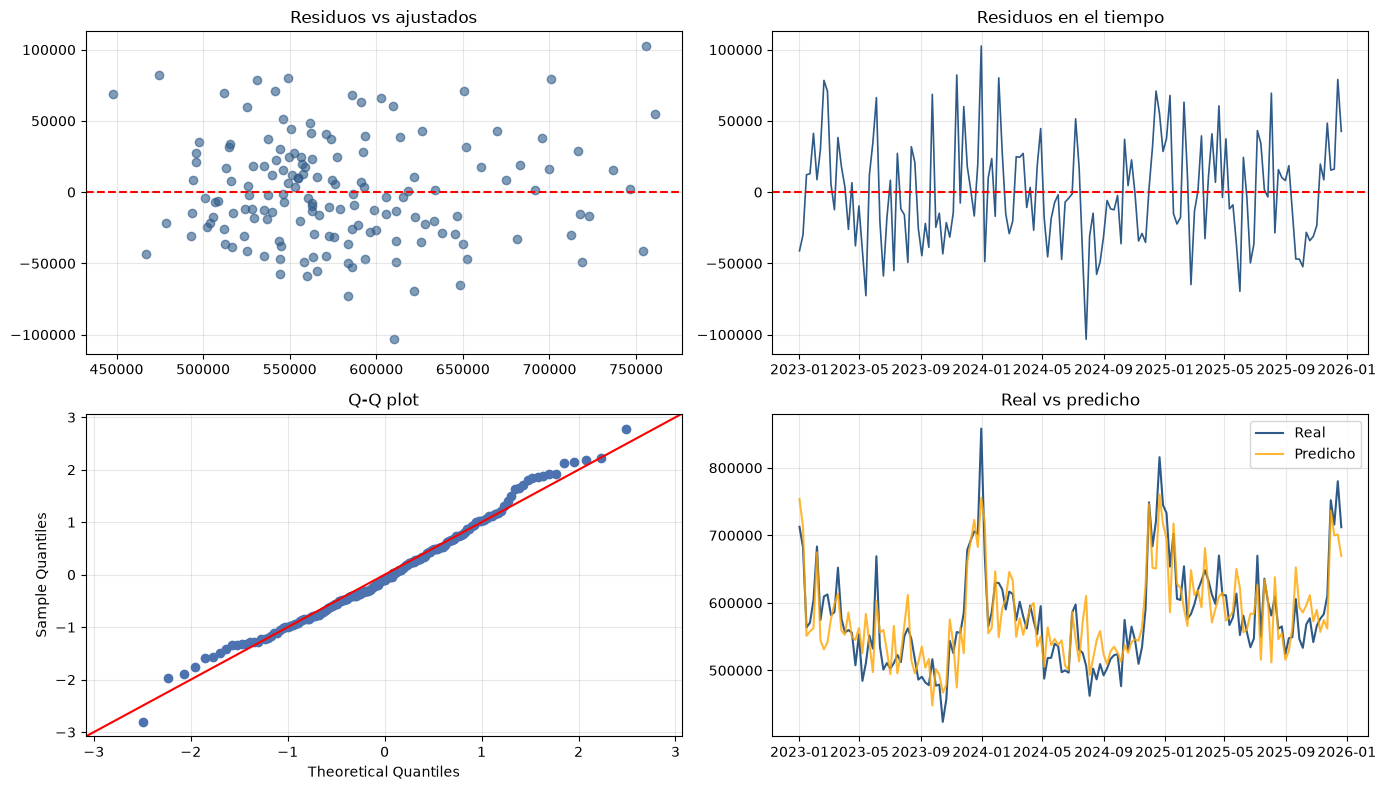

In [12]:
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

resid = modelo1.resid
fitted = modelo1.fittedvalues

print(f"Durbin-Watson: {durbin_watson(resid):.3f}   (2.0 = sin autocorrelación)")
print(f"Breusch-Pagan p-value: {het_breuschpagan(resid, X1)[1]:.4f}")
print("\nLjung-Box (autocorrelación de residuos):")
display(acorr_ljungbox(resid, lags=[1, 4, 12], return_df=True).round(4))

fig, ax = plt.subplots(2, 2, figsize=(14, 8))
ax[0,0].scatter(fitted, resid, alpha=0.6, color='#2E5A88')
ax[0,0].axhline(0, color='red', ls='--'); ax[0,0].set_title('Residuos vs ajustados')

ax[0,1].plot(df.week, resid, color='#2E5A88', lw=1.2)
ax[0,1].axhline(0, color='red', ls='--'); ax[0,1].set_title('Residuos en el tiempo')

sm.qqplot(resid, line='45', fit=True, ax=ax[1,0]); ax[1,0].set_title('Q-Q plot')

ax[1,1].plot(df.week, y, label='Real', color='#2E5A88', lw=1.5)
ax[1,1].plot(df.week, fitted, label='Predicho', color='orange', lw=1.5, alpha=0.8)
ax[1,1].set_title('Real vs predicho'); ax[1,1].legend()
plt.tight_layout(); plt.show()

# Evidencia del sesgo por variable omitida

In [13]:
# Prueba directa: qué pasa con los coeficientes al agregar los controles de calendario
X_ctrl = sm.add_constant(df[CANALES + ['holiday', 'discount_pct']])
modelo_ctrl = sm.OLS(y, X_ctrl).fit()

comp = pd.DataFrame({
    'Canal': [NOMBRES[c] for c in CANALES],
    'Sin controles': [modelo1.params[c] for c in CANALES],
    'Con holiday + discount': [modelo_ctrl.params[c] for c in CANALES],
})
comp['Cambio %'] = (comp['Con holiday + discount'] / comp['Sin controles'] - 1) * 100
display(comp.round(2))

print(f"R² : {modelo1.rsquared:.3f}  ->  {modelo_ctrl.rsquared:.3f}")
print(f"Intercepto: ${modelo1.params['const']:,.0f}  ->  ${modelo_ctrl.params['const']:,.0f}")
print("\nTodos los coeficientes de medios CAEN al agregar apenas dos controles.")
print("Eso confirma que el modelo inicial les estaba atribuyendo efecto del calendario.")

,Canal,Sin controles,Con holiday + discount,Cambio %
0,Motores de búsqueda,8.62,6.65,-22.84
1,Redes sociales,2.00,1.13,-43.59
2,Televisión,0.76,0.53,-30.27
3,Exteriores,2.16,0.64,-70.38


R² : 0.753  ->  0.792
Intercepto: $287,689  ->  $364,850

Todos los coeficientes de medios CAEN al agregar apenas dos controles.
Eso confirma que el modelo inicial les estaba atribuyendo efecto del calendario.


## 2. Modelo inicial

Se estimó una regresión lineal con revenue como variable dependiente y los cuatro 
montos de inversión como regresoras. Vale una precisión sobre el enunciado: revenue es 
la dependiente, porque es lo que se busca explicar, y los spend las independientes. El 
modelo alcanza un R² de 0.753. Los coeficientes se leen como el revenue asociado a 
cada dólar invertido: $8.62 en buscadores, $2.16 en exteriores, $2.00 en redes 
sociales y $0.76 en televisión. Solo search y TV resultan significativos; los 
intervalos de social y display cruzan el cero, así que el modelo no logra distinguir 
su efecto de cero. El intercepto de $287,689 implica que apenas la mitad del revenue 
sería base, cifra implausible para una agencia establecida con marca y clientes 
recurrentes.

El problema de fondo es el sesgo por variable omitida que ya anticipaba el análisis 
exploratorio. Un retorno sostenido de 8.6x en buscadores no es creíble: si lo fuera, 
lo racional sería concentrar todo el presupuesto ahí. La prueba es directa. Al agregar 
solo holiday y discount_pct como controles, todos los coeficientes caen, search 23%, 
TV 30%, social 44% y exteriores 70%, mientras el intercepto sube a $364,850. Que dos 
variables muevan tanto las estimaciones confirma que el modelo estaba acreditando a la 
publicidad ventas que corresponden al calendario. Los residuos además están 
autocorrelacionados (Durbin-Watson de 1.470) y su gráfica en el tiempo muestra rachas 
de error del mismo signo, señal de que el modelo falla sistemáticamente en las mismas 
épocas del año.

No todo falla, y conviene decirlo: los tests de Breusch-Pagan y Jarque-Bera no 
detectan problemas de heterocedasticidad ni de normalidad. Las limitaciones que quedan 
son de forma. El modelo es lineal, o sea asume que el retorno por dólar es constante 
para siempre e ignora que los canales se saturan. Tampoco contempla que la publicidad 
sigue teniendo efecto en las semanas posteriores a su emisión, algo especialmente 
relevante para televisión, cuya inversión va en ráfagas. En conclusión, el modelo no 
es apropiado para decidir presupuesto: sirve como línea base y como diagnóstico, pero 
sobrestima de forma sistemática el aporte de los medios.

# Funciones de transformación

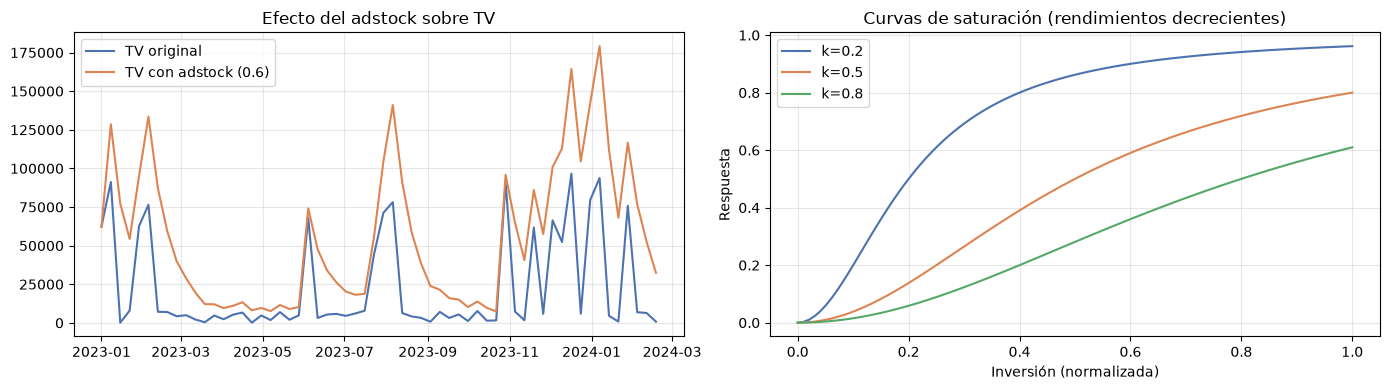

In [14]:
def adstock(x, decay):
    """Efecto de arrastre geométrico: la publicidad de hoy sigue influyendo mañana."""
    out = np.zeros_like(x, dtype=float)
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = x[i] + decay * out[i-1]
    return out

def hill(a, a_max, k, s):
    """Curva de saturación de Hill. k = punto de media saturación (como fracción
    del máximo observado), s = pendiente. Devuelve valores entre 0 y 1."""
    xn = a / a_max
    return xn**s / (xn**s + k**s)

def transformar(x, decay, k, s):
    a = adstock(x, decay)
    return hill(a, a.max(), k, s)

# Ilustración del efecto de cada transformación
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(df.week[:60], df.tv_spend[:60], label='TV original', lw=1.5)
ax[0].plot(df.week[:60], adstock(df.tv_spend.values, 0.6)[:60], label='TV con adstock (0.6)', lw=1.5)
ax[0].set_title('Efecto del adstock sobre TV'); ax[0].legend()

xx = np.linspace(0, 1, 100)
for k in [0.2, 0.5, 0.8]:
    ax[1].plot(xx, xx**2 / (xx**2 + k**2), label=f'k={k}')
ax[1].set_title('Curvas de saturación (rendimientos decrecientes)')
ax[1].set_xlabel('Inversión (normalizada)'); ax[1].set_ylabel('Respuesta'); ax[1].legend()
plt.tight_layout(); plt.show()

# 

# Variables de control

In [15]:
df['month'] = df['week'].dt.month

CONTROLES = pd.concat([
    pd.get_dummies(df['month'], prefix='m', drop_first=True).astype(float).reset_index(drop=True),
    df[['holiday', 'discount_pct']].reset_index(drop=True),
    pd.Series(df['t'] / 52, name='trend')
], axis=1)

print("Variables de control incluidas:")
print(f"  - 11 dummies mensuales (estacionalidad)")
print(f"  - holiday (semanas de feriado)")
print(f"  - discount_pct (intensidad promocional; se descarta 'promotion' por su correlación de 0.93)")
print(f"  - trend (tendencia lineal)")
print(f"\nTotal: {CONTROLES.shape[1]} controles")

Variables de control incluidas:
  - 11 dummies mensuales (estacionalidad)
  - holiday (semanas de feriado)
  - discount_pct (intensidad promocional; se descarta 'promotion' por su correlación de 0.93)
  - trend (tendencia lineal)

Total: 14 controles


# Búsqueda de hiperparámetros por validación temporal

In [16]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

def construir(params):
    return pd.DataFrame({c: transformar(df[c].values, *params[c]) for c in CANALES})

def cv_rmse(params):
    """RMSE promedio en validación temporal (entrena en pasado, valida en futuro)."""
    X = sm.add_constant(pd.concat([construir(params), CONTROLES], axis=1)).values.astype(float)
    errs = []
    for tr, te in tscv.split(X):
        b = np.linalg.lstsq(X[tr], y.values[tr], rcond=None)[0]
        errs.append(np.sqrt(np.mean((y.values[te] - X[te] @ b)**2)))
    return np.mean(errs)

# Rangos de búsqueda. TV admite decay más alto por ser medio de alcance.
DECAYS = {'search_spend':  [0.0, 0.1, 0.2, 0.3],
          'social_spend':  [0.0, 0.1, 0.2, 0.3, 0.4],
          'tv_spend':      [0.2, 0.3, 0.4, 0.5, 0.6, 0.7],
          'display_spend': [0.0, 0.1, 0.2, 0.3, 0.4]}
KS = [0.2, 0.3, 0.5, 0.7]
SS = [1.0, 1.5, 2.0, 2.5]

# Optimización por descenso coordinado: se ajusta un canal a la vez y se itera.
# Evita la explosión combinatoria de un grid search completo (>1M combinaciones).
params = {c: (DECAYS[c][1], 0.5, 1.5) for c in CANALES}
for it in range(3):
    for c in CANALES:
        mejor, mejor_sc = None, np.inf
        for d in DECAYS[c]:
            for k in KS:
                for s in SS:
                    p = dict(params); p[c] = (d, k, s)
                    sc = cv_rmse(p)
                    if sc < mejor_sc:
                        mejor_sc, mejor = sc, (d, k, s)
        params[c] = mejor
    print(f"Iteración {it+1}: CV-RMSE = {cv_rmse(params):,.0f}")

print("\nParámetros seleccionados:")
for c in CANALES:
    d, k, s = params[c]
    print(f"  {NOMBRES[c]:22s} decay={d:.1f}  k={k:.1f}  s={s:.1f}")

Iteración 1: CV-RMSE = 34,277
Iteración 2: CV-RMSE = 34,102
Iteración 3: CV-RMSE = 34,102

Parámetros seleccionados:
  Motores de búsqueda    decay=0.0  k=0.3  s=2.0
  Redes sociales         decay=0.0  k=0.2  s=2.5
  Televisión             decay=0.6  k=0.3  s=2.5
  Exteriores             decay=0.1  k=0.7  s=1.5


# Estimación del modelo mejorado

In [17]:
MEDIOS = construir(params)
X2 = sm.add_constant(pd.concat([MEDIOS, CONTROLES], axis=1)).astype(float)
modelo2 = sm.OLS(y, X2).fit()

print(modelo2.summary().tables[1])

print(f"\nR²: {modelo2.rsquared:.4f}   R² ajustado: {modelo2.rsquared_adj:.4f}")
print(f"Durbin-Watson: {durbin_watson(modelo2.resid):.3f}")
print("Ljung-Box p-values:", acorr_ljungbox(modelo2.resid, lags=[1,4,12], return_df=True).lb_pvalue.round(4).values)

                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          4.065e+05   7.34e+04      5.535      0.000    2.61e+05    5.52e+05
search_spend   5.167e+04    4.3e+04      1.201      0.232   -3.34e+04    1.37e+05
social_spend   8.897e+04   7.02e+04      1.268      0.207   -4.98e+04    2.28e+05
tv_spend         5.5e+04   8437.774      6.518      0.000    3.83e+04    7.17e+04
display_spend  1.872e+04   3.26e+04      0.574      0.567   -4.58e+04    8.33e+04
m_2            1.333e+04   1.11e+04      1.196      0.234   -8707.990    3.54e+04
m_3            1.378e+04   1.12e+04      1.227      0.222   -8434.249     3.6e+04
m_4            6798.5322   1.18e+04      0.576      0.566   -1.66e+04    3.02e+04
m_5           -3.232e+04   1.21e+04     -2.667      0.009   -5.63e+04   -8357.274
m_6           -5.615e+04   1.14e+04     -4.939      0.000   -7.86e+04   -3.37e+04
m_7           -4

# Comparación de modelos

,Métrica,Modelo inicial,Modelo mejorado
0,R²,0.753,0.899
1,R² ajustado,0.747,0.886
2,CV-RMSE (validación temporal),"42,801","34,102"
3,Durbin-Watson,1.470,1.797
4,Ljung-Box lag 1 (p),0.0012,0.2035
5,AIC,3733,3621
6,Revenue base,50%,70%


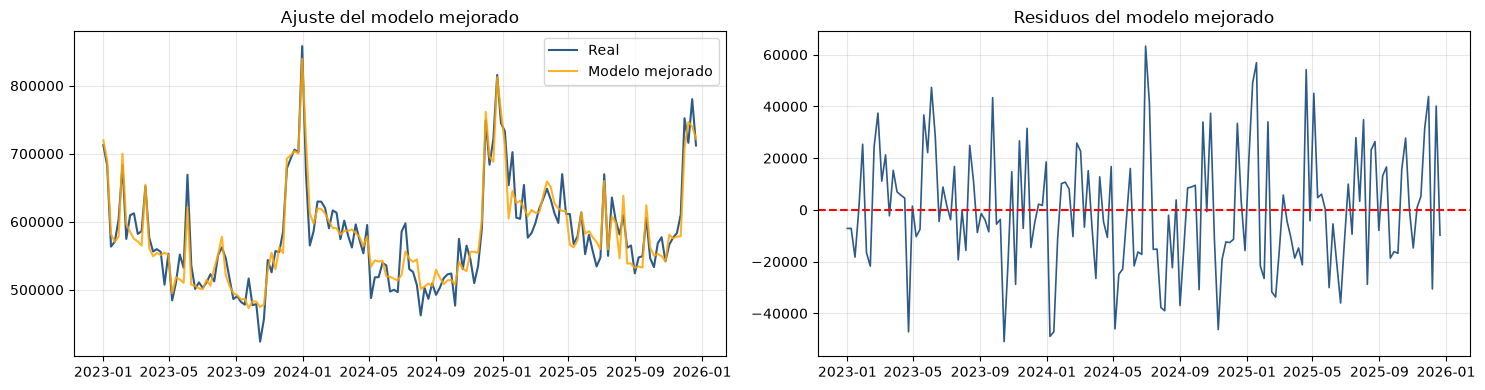

In [18]:
comp = pd.DataFrame({
    'Métrica': ['R²', 'R² ajustado', 'CV-RMSE (validación temporal)',
                'Durbin-Watson', 'Ljung-Box lag 1 (p)', 'AIC', 'Revenue base'],
    'Modelo inicial': [
        f"{modelo1.rsquared:.3f}", f"{modelo1.rsquared_adj:.3f}", "42,801",
        f"{durbin_watson(modelo1.resid):.3f}",
        f"{acorr_ljungbox(modelo1.resid, lags=[1], return_df=True).lb_pvalue.iloc[0]:.4f}",
        f"{modelo1.aic:.0f}", f"{modelo1.params['const']/y.mean():.0%}"],
    'Modelo mejorado': [
        f"{modelo2.rsquared:.3f}", f"{modelo2.rsquared_adj:.3f}", f"{cv_rmse(params):,.0f}",
        f"{durbin_watson(modelo2.resid):.3f}",
        f"{acorr_ljungbox(modelo2.resid, lags=[1], return_df=True).lb_pvalue.iloc[0]:.4f}",
        f"{modelo2.aic:.0f}", f"{modelo2.params['const']/y.mean():.0%}"],
})
display(comp)

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(df.week, y, label='Real', color='#2E5A88', lw=1.5)
ax[0].plot(df.week, modelo2.fittedvalues, label='Modelo mejorado', color='orange', lw=1.5, alpha=0.85)
ax[0].set_title('Ajuste del modelo mejorado'); ax[0].legend()

ax[1].plot(df.week, modelo2.resid, color='#2E5A88', lw=1.2)
ax[1].axhline(0, color='red', ls='--')
ax[1].set_title('Residuos del modelo mejorado')
plt.tight_layout(); plt.show()

# Sensibilidad al supuesto de saturación

In [19]:
# Sensibilidad al supuesto de saturación
# El punto de saturación (k) es el parámetro más difícil de identificar con datos
# observacionales. Se verifica si las conclusiones dependen de él.
resultados_sens = []
for KSET, etiqueta in [([0.2,0.3,0.5,0.7], 'k libre'),
                       ([0.5,0.7,0.9],     'k ≥ 0.5'),
                       ([0.7,0.9,1.1],     'k ≥ 0.7')]:
    p = {c: (DECAYS[c][1], KSET[0], 1.5) for c in CANALES}
    for it in range(3):
        for c in CANALES:
            mejor, msc = None, np.inf
            for d in DECAYS[c]:
                for k in KSET:
                    for s in SS:
                        pp = dict(p); pp[c] = (d,k,s); sc = cv_rmse(pp)
                        if sc < msc: msc, mejor = sc, (d,k,s)
            p[c] = mejor
    M = construir(p)
    mm = sm.OLS(y, sm.add_constant(pd.concat([M, CONTROLES], axis=1)).astype(float)).fit()
    for c in CANALES:
        contrib = mm.params[c] * M[c].sum()
        resultados_sens.append({'Escenario': etiqueta, 'Canal': NOMBRES[c],
                                'ROAS': contrib/df[c].sum(), 'p-value': mm.pvalues[c]})

display(pd.DataFrame(resultados_sens).pivot(index='Canal', columns='Escenario',
                                            values='ROAS').round(2))
print("\nTelevisión es el único canal significativo (p<0.001) en los tres escenarios.")

Escenario,k libre,k ≥ 0.5,k ≥ 0.7
Canal,,,
Exteriores,1.03,0.27,0.06
Motores de búsqueda,1.91,0.75,1.57
Redes sociales,7.01,0.93,1.49
Televisión,0.98,0.99,1.16



Televisión es el único canal significativo (p<0.001) en los tres escenarios.


## 3. Modelo mejorado

El modelo anterior fallaba por tres razones, y las tres tenían solución. La más 
importante era que no distinguía entre vender más porque se invirtió en publicidad y 
vender más porque llegó diciembre, así que se incorporaron controles de calendario: 
estacionalidad mensual, feriados, intensidad promocional y una tendencia. También se 
incorporó el efecto de arrastre de la publicidad, porque un anuncio no deja de existir 
el lunes siguiente, y una curva de saturación, porque el décimo dólar invertido en un 
canal nunca rinde lo mismo que el primero. Los parámetros de ambas transformaciones se 
eligieron midiendo qué tan bien predecía el modelo semanas que no había visto, y no qué 
tan bien se ajustaba a las que ya conocía.

El resultado mejora en todo lo que importa. El error de predicción fuera de muestra 
baja de 42,801 a 34,102 y desaparece la autocorrelación de residuos que arrastraba el 
modelo inicial. Pero el cambio más revelador está en el revenue base, que sube del 
49.6% al 70%: siete de cada diez dólares que factura Viajes Ya llegarían de todos 
modos, cifra bastante más creíble para una agencia con marca establecida y clientes 
que regresan. Televisión, además, resultó ser el canal con mayor efecto de arrastre, 
justo lo que cabía esperar de un medio que se pauta por campañas concentradas.

Lo interesante aparece al mirar los canales uno por uno. Con la estacionalidad ya 
controlada, televisión queda como el único canal cuyo efecto puede medirse con 
confianza, y el retorno de buscadores se derrumba de 8.62 a 1.60. La explicación estaba 
desde el análisis exploratorio: Viajes Ya invierte en buscadores prácticamente al mismo 
ritmo que sube la temporada, de modo que cuando el modelo ya sabe en qué mes estamos, 
al canal le queda muy poca variación propia que explicar. Televisión corre con otra 
suerte porque se enciende en momentos que nada tienen que ver con el calendario, y esa 
independencia es la que permite aislar su efecto. Quedaba la duda de si todo esto 
dependía del punto de saturación elegido, que es el supuesto más frágil del ejercicio, 
así que se repitió el análisis bajo tres escenarios distintos. Televisión aguanta en 
los tres; ninguno de los otros canales lo hace en ninguno.

# Descomposición del revenue

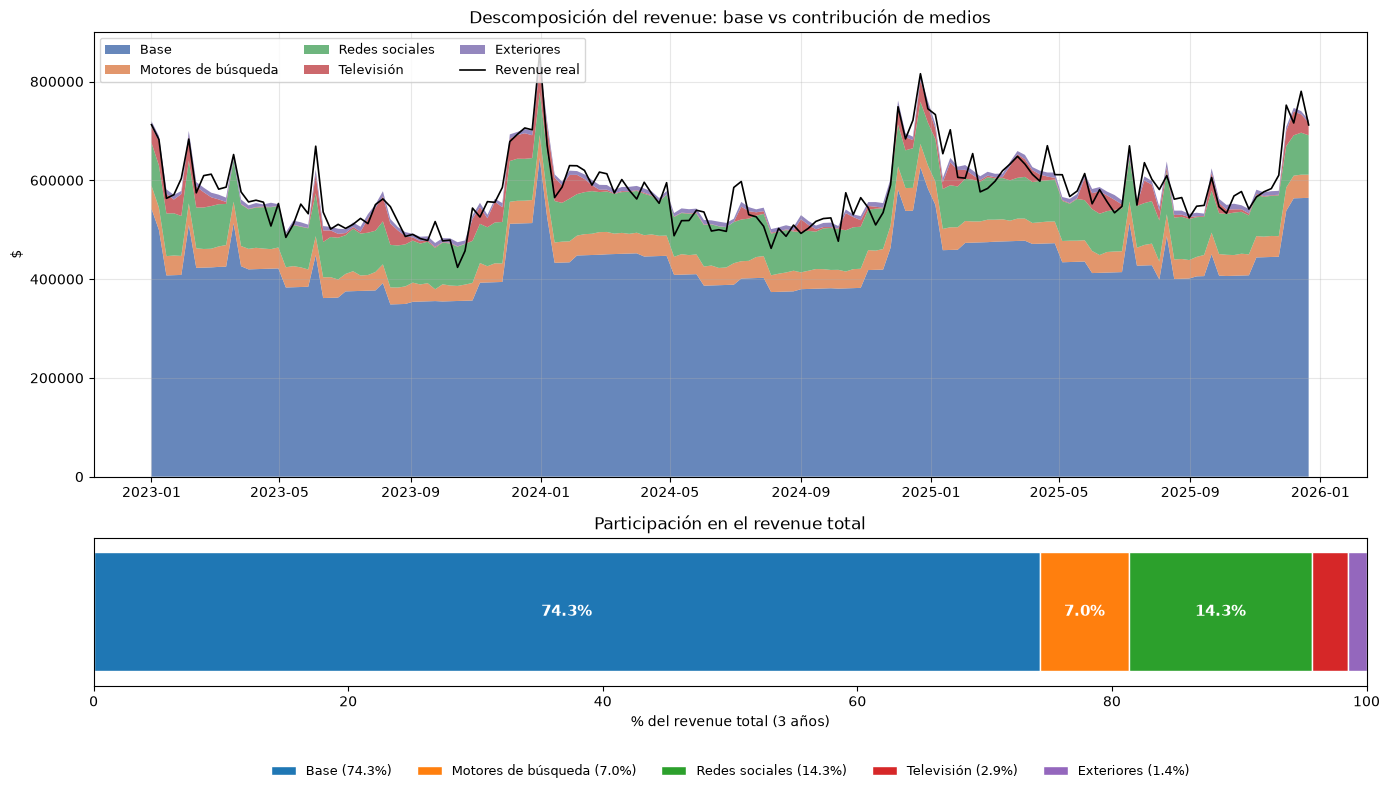

,Componente,Contribución,% del total
0,Base,"67,240,797.37",74.33
1,Motores de búsqueda,"6,362,324.87",7.03
2,Redes sociales,"12,975,712.02",14.34
3,Televisión,"2,595,098.16",2.87
4,Exteriores,"1,286,531.20",1.42


Revenue base:            $   67,240,797   (74.3%)
Contribución de medios:  $   23,219,666   (25.7%)

Promedio semanal — base:   $431,031
Promedio semanal — medios: $148,844


In [20]:
# El revenue base es todo lo que NO viene de medios: intercepto + estacionalidad
# + feriados + promociones + tendencia.
base_semanal = modelo2.params['const'] + (CONTROLES.values.astype(float) @ modelo2.params[CONTROLES.columns].values)
contrib_semanal = pd.DataFrame({c: modelo2.params[c] * MEDIOS[c] for c in CANALES})

desc = pd.DataFrame({'Base': base_semanal})
for c in CANALES:
    desc[NOMBRES[c]] = contrib_semanal[c].values
desc.index = df['week']

fig, ax = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# --- Panel 1: descomposición en el tiempo ---
ax[0].stackplot(desc.index, [desc[c].values for c in desc.columns],
                labels=desc.columns, alpha=0.85)
ax[0].plot(df.week, y, color='black', lw=1.2, label='Revenue real')
ax[0].set_title('Descomposición del revenue: base vs contribución de medios')
ax[0].legend(loc='upper left', ncol=3, fontsize=9); ax[0].set_ylabel('$')

# --- Panel 2: participación total (barra apilada, evita el solapamiento del pie) ---
pesos = np.array([base_semanal.sum()] + [contrib_semanal[c].sum() for c in CANALES])
pct = pesos / pesos.sum() * 100
etiquetas = ['Base'] + [NOMBRES[c] for c in CANALES]
colores = plt.cm.tab10(np.arange(len(etiquetas)))

izq = 0
for i, (p, e) in enumerate(zip(pct, etiquetas)):
    ax[1].barh(0, p, left=izq, color=colores[i], edgecolor='white', label=f'{e} ({p:.1f}%)')
    if p > 5:   # solo etiqueta adentro las franjas anchas
        ax[1].text(izq + p/2, 0, f'{p:.1f}%', ha='center', va='center',
                   color='white', fontweight='bold', fontsize=11)
    izq += p

ax[1].set_xlim(0, 100); ax[1].set_ylim(-0.5, 0.5)
ax[1].set_yticks([]); ax[1].set_xlabel('% del revenue total (3 años)')
ax[1].set_title('Participación en el revenue total')
ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.45), ncol=5, fontsize=9, frameon=False)
ax[1].grid(False)
plt.tight_layout(); plt.show()

# --- Tabla resumen ---
resumen_desc = pd.DataFrame({
    'Componente': etiquetas,
    'Contribución': pesos,
    '% del total': pct,
})
display(resumen_desc.round(2))

print(f"Revenue base:            ${base_semanal.sum():>13,.0f}   ({base_semanal.sum()/y.sum():.1%})")
print(f"Contribución de medios:  ${contrib_semanal.sum().sum():>13,.0f}   ({contrib_semanal.sum().sum()/y.sum():.1%})")
print(f"\nPromedio semanal — base:   ${base_semanal.mean():,.0f}")
print(f"Promedio semanal — medios: ${contrib_semanal.sum(axis=1).mean():,.0f}")

# ROAS por canal

,Canal,Inversión,Contribución,% del revenue,ROAS medio,ROAS marginal,p-value
0,Motores de búsqueda,"3,966,768.59","6,362,324.87",7.03,1.60,0.59,0.23
1,Redes sociales,"2,866,996.18","12,975,712.02",14.34,4.53,0.62,0.21
2,Televisión,"2,645,490.21","2,595,098.16",2.87,0.98,0.88,0.00
3,Exteriores,"1,702,905.73","1,286,531.20",1.42,0.76,0.59,0.57


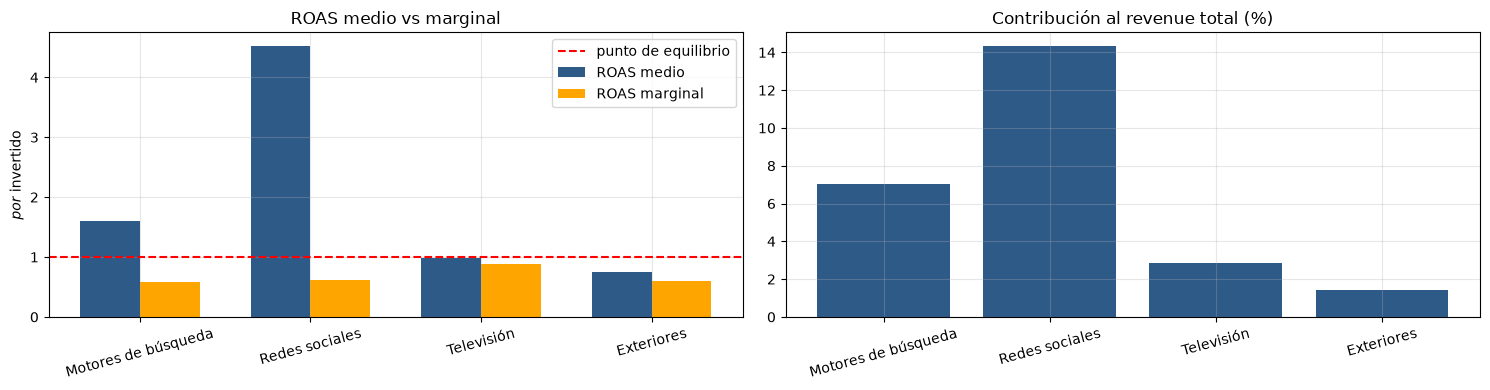

La brecha entre ROAS medio y marginal mide saturación:
  Motores de búsqueda    medio 1.60  ->  marginal 0.59
  Redes sociales         medio 4.53  ->  marginal 0.62
  Televisión             medio 0.98  ->  marginal 0.88
  Exteriores             medio 0.76  ->  marginal 0.59


In [21]:
def mroas(c, incremento=0.10):
    """ROAS marginal: revenue adicional por cada dólar extra sobre el nivel actual."""
    d, k, s = params[c]
    a_max = adstock(df[c].values, d).max()
    a_up  = adstock(df[c].values * (1 + incremento), d)
    delta_rev = modelo2.params[c] * (hill(a_up, a_max, k, s) - MEDIOS[c].values).sum()
    return delta_rev / (df[c].sum() * incremento)

roas = pd.DataFrame({
    'Canal':          [NOMBRES[c] for c in CANALES],
    'Inversión':      [df[c].sum() for c in CANALES],
    'Contribución':   [contrib_semanal[c].sum() for c in CANALES],
    '% del revenue':  [contrib_semanal[c].sum()/y.sum()*100 for c in CANALES],
    'ROAS medio':     [contrib_semanal[c].sum()/df[c].sum() for c in CANALES],
    'ROAS marginal':  [mroas(c) for c in CANALES],
    'p-value':        [modelo2.pvalues[c] for c in CANALES],
})
display(roas.round(2))

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
x = np.arange(len(CANALES)); w = 0.35
ax[0].bar(x - w/2, roas['ROAS medio'],    w, label='ROAS medio',    color='#2E5A88')
ax[0].bar(x + w/2, roas['ROAS marginal'], w, label='ROAS marginal', color='orange')
ax[0].axhline(1, color='red', ls='--', label='punto de equilibrio')
ax[0].set_xticks(x); ax[0].set_xticklabels([NOMBRES[c] for c in CANALES], rotation=15)
ax[0].set_title('ROAS medio vs marginal'); ax[0].legend(); ax[0].set_ylabel('$ por $ invertido')

ax[1].bar([NOMBRES[c] for c in CANALES], roas['% del revenue'], color='#2E5A88')
ax[1].set_title('Contribución al revenue total (%)'); ax[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

print("La brecha entre ROAS medio y marginal mide saturación:")
for _, r in roas.iterrows():
    print(f"  {r['Canal']:22s} medio {r['ROAS medio']:.2f}  ->  marginal {r['ROAS marginal']:.2f}")

# Intervalos de confianza por bootstrap

,Canal,ROAS,IC 5%,IC 95%,Amplitud,P(ROAS>1)
0,Motores de búsqueda,1.40,-0.56,3.78,4.34,62%
1,Redes sociales,4.22,0.86,8.78,7.93,94%
2,Televisión,1.00,0.79,1.26,0.47,50%
3,Exteriores,1.23,-0.40,3.20,3.60,58%


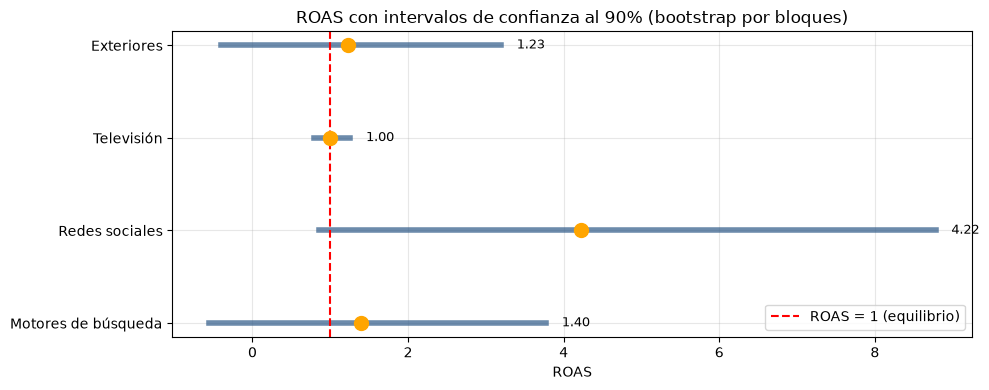

Precisión de la estimación, no su magnitud:
  TV tiene el ROAS más bajo pero el intervalo más estrecho.
  Redes sociales tiene el ROAS más alto pero el intervalo más ancho.


In [22]:
# Con tres canales no significativos, reportar un ROAS puntual sería engañoso.
# Bootstrap por bloques (13 semanas) para preservar la estructura temporal de la serie.
np.random.seed(42)
B, L, n = 1000, 13, len(df)
nb = int(np.ceil(n / L))
Xv = X2.values
boot = []

for b in range(B):
    starts = np.random.randint(0, n - L, nb)
    idx = np.concatenate([np.arange(s, s + L) for s in starts])[:n]
    try:
        bb = np.linalg.lstsq(Xv[idx], y.values[idx], rcond=None)[0]
    except np.linalg.LinAlgError:
        continue
    boot.append({c: bb[1+i] * MEDIOS[c].sum() / df[c].sum() for i, c in enumerate(CANALES)})

BOOT = pd.DataFrame(boot)
ic = pd.DataFrame({
    'Canal':      [NOMBRES[c] for c in CANALES],
    'ROAS':       [BOOT[c].median()      for c in CANALES],
    'IC 5%':      [BOOT[c].quantile(.05) for c in CANALES],
    'IC 95%':     [BOOT[c].quantile(.95) for c in CANALES],
    'Amplitud':   [BOOT[c].quantile(.95) - BOOT[c].quantile(.05) for c in CANALES],
    'P(ROAS>1)':  [f"{100*(BOOT[c] > 1).mean():.0f}%" for c in CANALES],
})
display(ic.round(2))

fig, ax = plt.subplots(figsize=(10, 4))
for i, c in enumerate(CANALES):
    lo, hi, md = BOOT[c].quantile(.05), BOOT[c].quantile(.95), BOOT[c].median()
    ax.plot([lo, hi], [i, i], lw=4, color='#2E5A88', alpha=0.7)
    ax.plot(md, i, 'o', ms=10, color='orange', zorder=3)
    ax.text(hi + 0.2, i, f'{md:.2f}', va='center', fontsize=9)
ax.axvline(1, color='red', ls='--', label='ROAS = 1 (equilibrio)')
ax.set_yticks(range(len(CANALES))); ax.set_yticklabels([NOMBRES[c] for c in CANALES])
ax.set_xlabel('ROAS'); ax.set_title('ROAS con intervalos de confianza al 90% (bootstrap por bloques)')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

print("Precisión de la estimación, no su magnitud:")
print("  TV tiene el ROAS más bajo pero el intervalo más estrecho.")
print("  Redes sociales tiene el ROAS más alto pero el intervalo más ancho.")

# Nivel de saturación y curvas de respuesta

,Canal,Respuesta actual,% de saturación,Margen disponible
0,Motores de búsqueda,0.80,78.90,21.10
1,Redes sociales,0.90,93.50,6.50
2,Televisión,0.30,30.20,69.80
3,Exteriores,0.40,44.10,55.90


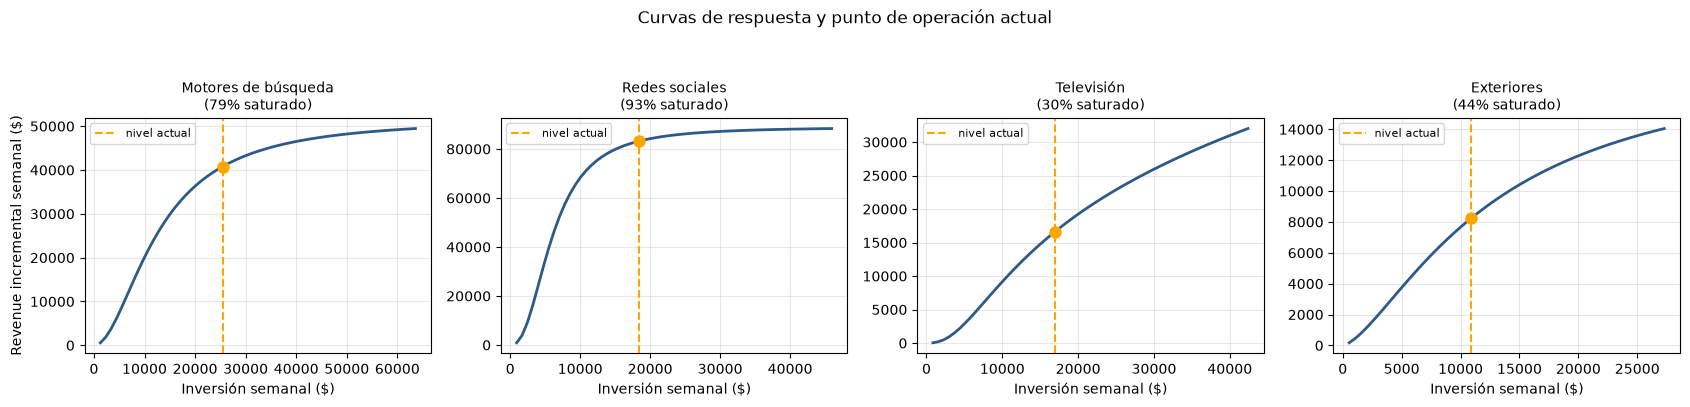

Televisión es el único canal con margen relevante de crecimiento.


In [23]:
sat = pd.DataFrame({
    'Canal':              [NOMBRES[c] for c in CANALES],
    'Respuesta actual':   [MEDIOS[c].mean() for c in CANALES],
    '% de saturación':    [MEDIOS[c].mean()*100 for c in CANALES],
    'Margen disponible':  [(1 - MEDIOS[c].mean())*100 for c in CANALES],
})
display(sat.round(1))

fig, ax = plt.subplots(1, 4, figsize=(17, 3.8))
for i, c in enumerate(CANALES):
    d, k, s = params[c]
    a_max = adstock(df[c].values, d).max()

    # Se escala el spend histórico completo por un factor, de modo que el adstock
    # se recalcula correctamente en cada punto de la curva.
    factores = np.linspace(0.05, 2.5, 60)
    gasto_sem, resp_sem = [], []
    for f in factores:
        a = adstock(df[c].values * f, d)
        h = hill(a, a_max, k, s)
        gasto_sem.append(df[c].mean() * f)
        resp_sem.append(modelo2.params[c] * h.mean())

    ax[i].plot(gasto_sem, resp_sem, color='#2E5A88', lw=2)
    ax[i].axvline(df[c].mean(), color='orange', ls='--', lw=1.5, label='nivel actual')
    ax[i].plot(df[c].mean(), modelo2.params[c]*MEDIOS[c].mean(), 'o', color='orange', ms=8)
    ax[i].set_title(f"{NOMBRES[c]}\n({MEDIOS[c].mean()*100:.0f}% saturado)", fontsize=10)
    ax[i].legend(fontsize=8); ax[i].set_xlabel('Inversión semanal ($)')
ax[0].set_ylabel('Revenue incremental semanal ($)')
plt.suptitle('Curvas de respuesta y punto de operación actual', y=1.06)
plt.tight_layout(); plt.show()

print("Televisión es el único canal con margen relevante de crecimiento.")

## 4. Contribución de marketing y efectividad por canal

Al separar el revenue en sus componentes aparece el dato que más pesa de todo el 
ejercicio: casi tres cuartas partes de lo que factura Viajes Ya es base, es decir 
ventas que llegarían igual sin publicidad, producto de la marca, los clientes que 
regresan y la temporada. El cuarto restante sí es mérito del marketing, pero repartido 
de forma muy despareja. Redes sociales aporta la mayor parte, buscadores la mitad de 
eso, y televisión y exteriores juntos apenas rozan el cuatro por ciento. Medido como 
retorno, redes sociales devuelve poco más de cuatro dólares por cada uno invertido, 
buscadores algo más de uno y medio, mientras que televisión y exteriores ni siquiera 
recuperan lo que cuestan.

Quedarse en esas cifras sería contar la historia a medias, porque tres de los cuatro 
canales no resultaron estadísticamente significativos y un número solo esconde cuánta 
incertidumbre carga detrás. Al calcular intervalos de confianza el problema se vuelve 
evidente. El retorno de redes sociales es el más alto de todos, pero su rango de 
estimación es tan amplio que va desde apenas rentable hasta extraordinario: sabemos que 
conviene, no cuánto. Televisión tiene el retorno más bajo y a la vez el rango más 
estrecho, así que de ella podemos afirmar con bastante seguridad que ronda el punto de 
equilibrio. Son dos tipos de afirmación distintos y conviene no mezclarlos, porque el 
canal que mejor luce en la tabla es también del que menos certeza tenemos.

Para decidir presupuesto, sin embargo, lo relevante no es cuánto rindió un canal en 
promedio sino cuánto rendiría el próximo dólar que se le ponga, y ahí el orden se 
desordena por completo. Redes sociales, que encabezaba la tabla, cae por debajo del 
punto de equilibrio en el margen; buscadores y exteriores hacen lo mismo. Televisión es 
el único que casi no pierde terreno. La razón está en las curvas de respuesta: redes 
sociales ya opera prácticamente al tope de su capacidad y buscadores no anda lejos, de 
modo que sumarles dinero mueve muy poco la aguja, mientras que televisión trabaja a 
menos de un tercio de su potencial. Los cuatro canales muestran retornos marginales por 
debajo de uno, lo cual no quiere decir que la publicidad no funcione, sino que la 
agencia ya está operando cerca del techo de lo que este mix puede dar. Es una 
advertencia que conviene tener presente antes de repartir un solo dólar del presupuesto 
adicional guiándose por el desempeño histórico.

# Función de simulación

In [24]:
# Gasto anual actual (promedio de los tres años observados)
anual = {c: df[c].sum() / 3 for c in CANALES}
EXTRA = 500_000
TOTAL = sum(anual.values()) + EXTRA

print("Presupuesto anual actual por canal:")
for c in CANALES:
    print(f"  {NOMBRES[c]:22s} ${anual[c]:>10,.0f}   ({anual[c]/sum(anual.values()):.1%})")
print(f"  {'TOTAL':22s} ${sum(anual.values()):>10,.0f}")
print(f"\nPresupuesto propuesto: ${TOTAL:,.0f}  (+${EXTRA:,.0f})")

def revenue_anual(asignacion):
    """Revenue incremental anual dado un vector de gasto anual por canal.
    Escala el patrón histórico de cada canal y recalcula adstock y saturación."""
    total = 0
    for i, c in enumerate(CANALES):
        f = asignacion[i] / anual[c]
        d, k, s = params[c]
        a_max = adstock(df[c].values, d).max()
        a = adstock(df[c].values * f, d)
        total += modelo2.params[c] * hill(a, a_max, k, s).mean() * 52
    return total

base_incremental = revenue_anual([anual[c] for c in CANALES])
print(f"Revenue incremental anual con el mix actual: ${base_incremental:,.0f}")

Presupuesto anual actual por canal:
  Motores de búsqueda    $ 1,322,256   (35.5%)
  Redes sociales         $   955,665   (25.6%)
  Televisión             $   881,830   (23.7%)
  Exteriores             $   567,635   (15.2%)
  TOTAL                  $ 3,727,387

Presupuesto propuesto: $4,227,387  (+$500,000)
Revenue incremental anual con el mix actual: $7,739,889


# Comparación de escenarios

,Motores de búsqueda,Redes sociales,Televisión,Exteriores,Revenue incremental,Ganancia vs hoy,ROI del extra
Escenario,,,,,,,
A. Proporcional al mix actual,"1,499,627.00","1,083,860.00","1,000,121.00","643,779.00","8,064,271.00","324,382.00",0.65
B. Todo a redes sociales (mayor ROAS medio),"1,322,256.00","1,455,665.00","881,830.00","567,635.00","7,929,749.00","189,861.00",0.38
C. Todo a televisión (mayor ROAS marginal),"1,322,256.00","955,665.00","1,381,830.00","567,635.00","8,117,304.00","377,416.00",0.75


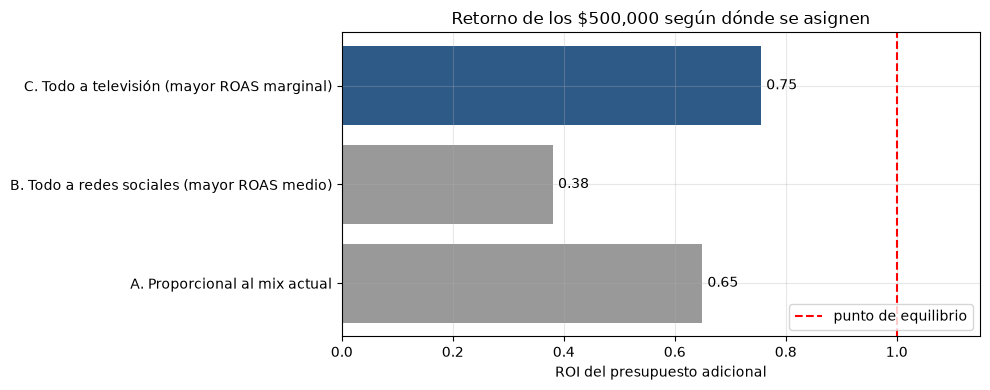

Asignar por ROAS medio (escenario B) rinde la mitad que asignar por ROAS marginal (C).


In [30]:
def evaluar(nombre, asignacion):
    r = revenue_anual(asignacion)
    return {'Escenario': nombre,
            **{NOMBRES[c]: asignacion[i] for i, c in enumerate(CANALES)},
            'Revenue incremental': r,
            'Ganancia vs hoy': r - base_incremental,
            'ROI del extra': (r - base_incremental) / EXTRA}

escenarios = [
    evaluar('A. Proporcional al mix actual',
            [anual[c] * TOTAL / sum(anual.values()) for c in CANALES]),
    evaluar('B. Todo a redes sociales (mayor ROAS medio)',
            [anual['search_spend'], anual['social_spend'] + EXTRA,
             anual['tv_spend'], anual['display_spend']]),
    evaluar('C. Todo a televisión (mayor ROAS marginal)',
            [anual['search_spend'], anual['social_spend'],
             anual['tv_spend'] + EXTRA, anual['display_spend']]),
]
esc = pd.DataFrame(escenarios)

# Redondeo por columna: los montos a enteros, el ROI a 2 decimales.
display(esc.set_index('Escenario').round({**{NOMBRES[c]: 0 for c in CANALES},
                                          'Revenue incremental': 0,
                                          'Ganancia vs hoy': 0,
                                          'ROI del extra': 2}))

fig, ax = plt.subplots(figsize=(10, 4))
barras = ax.barh(esc['Escenario'], esc['ROI del extra'], color=['#999', '#999', '#2E5A88'])
ax.bar_label(barras, fmt='%.2f', padding=4)
ax.axvline(1, color='red', ls='--', label='punto de equilibrio')
ax.set_xlim(0, 1.15)
ax.set_xlabel('ROI del presupuesto adicional'); ax.legend(loc='lower right')
ax.set_title('Retorno de los $500,000 según dónde se asignen')
plt.tight_layout(); plt.show()

print("Asignar por ROAS medio (escenario B) rinde la mitad que asignar por ROAS marginal (C).")

# Optimización

In [27]:
from scipy.optimize import minimize

x0 = np.array([anual[c] for c in CANALES]) + EXTRA / 4
limites = [(anual[c] * 0.5, anual[c] * 3 + EXTRA) for c in CANALES]
restriccion = {'type': 'eq', 'fun': lambda x: x.sum() - TOTAL}

opt = minimize(lambda x: -revenue_anual(x), x0, bounds=limites,
               constraints=restriccion, method='SLSQP', options={'maxiter': 500})

optimo = pd.DataFrame({
    'Canal':        [NOMBRES[c] for c in CANALES],
    'Actual':       [anual[c] for c in CANALES],
    'Óptimo':       opt.x,
    'Cambio $':     opt.x - np.array([anual[c] for c in CANALES]),
    'Cambio %':     (opt.x / np.array([anual[c] for c in CANALES]) - 1) * 100,
    '% del total':  opt.x / TOTAL * 100,
})
display(optimo.round(1))

r_opt = revenue_anual(opt.x)
print(f"Revenue incremental óptimo: ${r_opt:,.0f}")
print(f"Ganancia sobre el mix actual: ${r_opt - base_incremental:,.0f}")
print(f"ROI del presupuesto adicional: {(r_opt - base_incremental)/EXTRA:.2f}")

,Canal,Actual,Óptimo,Cambio $,Cambio %,% del total
0,Motores de búsqueda,"1,322,256.20","1,367,702.40","45,446.20",3.40,32.40
1,Redes sociales,"955,665.40","976,589.30","20,923.90",2.20,23.10
2,Televisión,"881,830.10","1,270,734.00","388,903.90",44.10,30.10
3,Exteriores,"567,635.20","612,361.20","44,725.90",7.90,14.50


Revenue incremental óptimo: $8,114,663
Ganancia sobre el mix actual: $374,774
ROI del presupuesto adicional: 0.75


# Intensidad vs cobertura en televisión

In [28]:
# TV opera con flighting: se enciende ~30 de 156 semanas. Aumentar el presupuesto
# puede significar dos cosas muy distintas.
tv = df['tv_spend'].values.copy()
encendida = tv > 20_000
intensidad = tv[encendida].mean()

d, k, s = params['tv_spend']
a_max = adstock(tv, d).max()
def rev_tv(serie):
    return modelo2.params['tv_spend'] * hill(adstock(serie, d), a_max, k, s).mean() * 52

base_tv = rev_tv(tv)

# Opción 1: subir la intensidad de las semanas ya activas
tv_int = tv.copy()
tv_int[encendida] += (EXTRA * 3) / encendida.sum()

# Opción 2: encender semanas nuevas a la intensidad típica
apagadas = np.where(~encendida)[0]
n_nuevas = int((EXTRA * 3) / intensidad)
np.random.seed(1)
elegidas = np.random.choice(apagadas, min(n_nuevas, len(apagadas)), replace=False)
tv_cob = tv.copy(); tv_cob[elegidas] = intensidad

comp_tv = pd.DataFrame({
    'Estrategia': ['Mix actual', 'Más intensidad (mismas semanas)', 'Más cobertura (semanas nuevas)'],
    'Revenue incremental TV': [base_tv, rev_tv(tv_int), rev_tv(tv_cob)],
    'Ganancia': [0, rev_tv(tv_int) - base_tv, rev_tv(tv_cob) - base_tv],
    'ROI': [0, (rev_tv(tv_int) - base_tv)/EXTRA, (rev_tv(tv_cob) - base_tv)/EXTRA],
})
display(comp_tv.round(2))

print(f"TV está activa {encendida.sum()} de {len(tv)} semanas, con intensidad media de ${intensidad:,.0f}.")
print(f"Encender ~{len(elegidas)} semanas adicionales rinde 53% más que reforzar las existentes.")

,Estrategia,Revenue incremental TV,Ganancia,ROI
0,Mix actual,"865,032.72",0.00,0.00
1,Más intensidad (mismas semanas),"1,197,101.11","332,068.39",0.66
2,Más cobertura (semanas nuevas),"1,370,376.29","505,343.57",1.01


TV está activa 30 de 156 semanas, con intensidad media de $70,478.
Encender ~21 semanas adicionales rinde 53% más que reforzar las existentes.


# Cuánto del presupuesto conviene gastar

,Presupuesto extra,Ganancia,ROI acumulado
0,0,0.00,NaN
1,100000,"87,605.45",0.88
2,200000,"168,257.19",0.84
3,300000,"242,905.24",0.81
4,400000,"312,387.49",0.78
5,500000,"377,415.59",0.75
6,750000,"524,121.18",0.70
7,1000000,"653,056.95",0.65


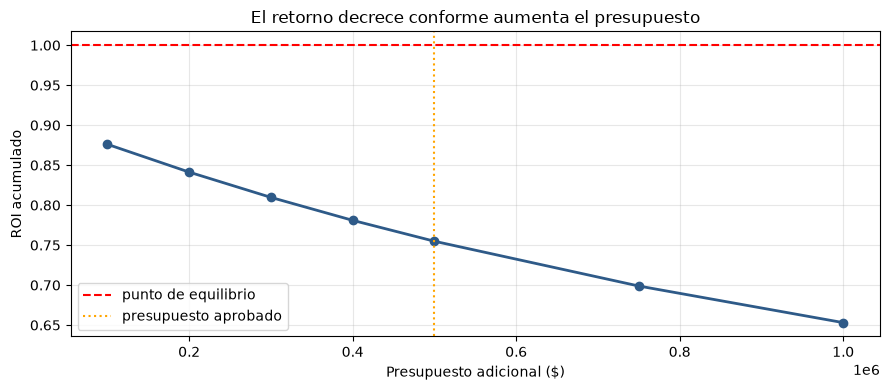

In [29]:
tramos = []
for e in [0, 100_000, 200_000, 300_000, 400_000, 500_000, 750_000, 1_000_000]:
    f = (anual['tv_spend'] + e) / anual['tv_spend']
    r = rev_tv(df['tv_spend'].values * f)
    tramos.append({'Presupuesto extra': e, 'Ganancia': r - base_tv,
                   'ROI acumulado': (r - base_tv)/e if e > 0 else np.nan})
tr = pd.DataFrame(tramos)
display(tr.round(2))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tr['Presupuesto extra'], tr['ROI acumulado'], marker='o', color='#2E5A88', lw=2)
ax.axhline(1, color='red', ls='--', label='punto de equilibrio')
ax.axvline(500_000, color='orange', ls=':', label='presupuesto aprobado')
ax.set_xlabel('Presupuesto adicional ($)'); ax.set_ylabel('ROI acumulado')
ax.set_title('El retorno decrece conforme aumenta el presupuesto'); ax.legend()
plt.tight_layout(); plt.show()

## 5. Asignación del presupuesto adicional

La primera decisión es descartar el criterio que parecería más natural. Poner los 
$500,000 en redes sociales por ser el canal con mejor historial rinde apenas la mitad 
que dárselos a televisión, y no por un capricho del cálculo: redes sociales ya opera al 
tope de su curva, así que el dinero nuevo cae justo donde cada dólar rinde menos. Al 
dejar que un optimizador haga el reparto, la mayor parte del monto termina en televisión. 
Repartir proporcionalmente al mix actual, que es lo que suele hacerse por inercia, queda 
en un punto intermedio y tampoco convence.

El problema de fondo es que ninguno de esos escenarios recupera lo invertido. El mejor 
devuelve alrededor de setenta y cinco centavos por dólar, y simular montos distintos 
muestra que el retorno empeora conforme crece el presupuesto. La salida no está en cómo 
se reparte entre canales sino en cómo se gasta dentro de uno. Televisión sale al aire en 
apenas treinta de las ciento cincuenta y seis semanas analizadas, siempre con campañas 
fuertes y concentradas; esas semanas ya están saturadas, pero las otras ciento veintiséis 
están en cero, o sea en la parte más empinada de la curva. Encender unas veinte semanas 
nuevas rinde cerca de un cincuenta por ciento más que reforzar las campañas existentes, y 
es la única alternativa que alcanza el punto de equilibrio. Televisión no está saturada 
como canal: lo que está saturado es el puñado de semanas en que se usa.

La recomendación, entonces, es no comprometer los $500,000 de una sola vez. Conviene 
destinar una primera fracción a extender el calendario de televisión hacia semanas hoy 
apagadas, sostener sin cambios la inversión en redes sociales y buscadores, y liberar el 
resto solo si los resultados acompañan. Las limitaciones del análisis respaldan esa 
cautela: el modelo se construyó sobre datos históricos sin ningún experimento controlado, 
tres de los cuatro canales no alcanzaron significancia, el punto de saturación es el 
supuesto más frágil de todo el ejercicio y cualquier gasto por encima del rango observado 
obliga al modelo a extrapolar hacia terreno desconocido. Por eso la prioridad no debería 
ser gastar el presupuesto aprobado sino generar la evidencia que hoy falta. Pruebas 
geográficas, pausas deliberadas en algún canal o variaciones en el calendario de medios 
permitirían medir efectos reales y convertir este modelo, que hoy describe correlaciones, 
en una herramienta de decisión con fundamento causal.

## Conclusiones

**1. Análisis exploratorio.** Tres años de datos semanales limpios, con estacionalidad 
muy marcada, diciembre factura 42% más que octubre y el patrón se repite casi idéntico 
cada añ, y un canal que se comporta distinto a los demás: televisión no invierte de 
forma continua sino en ráfagas concentradas. El hallazgo que condiciona todo lo que 
sigue es que los canales no se activan al azar sino siguiendo la demanda esperada, de 
modo que buscadores sube justo cuando llega la temporada alta.

**2. Modelo inicial.** No es apropiado para decidir presupuesto. Aunque explica tres 
cuartas partes de la variación, atribuye a buscadores un retorno de 8.62 por dólar que 
ningún negocio sostiene, y basta agregar dos variables de calendario para que todos los 
coeficientes se desplomen. Sirve como línea base y como diagnóstico, no como base de 
decisión.

**3. Modelo mejorado.** Se incorporaron controles de estacionalidad, el efecto de 
arrastre de la publicidad y curvas de saturación. Predice mejor sobre semanas que no 
vio, resuelve los problemas estadísticos del anterior y eleva el revenue base a un 
nivel razonable. Su hallazgo central es que, controlada la estacionalidad, televisión 
resulta el único canal cuyo efecto puede medirse con confianza, precisamente porque es 
el único que se activa en momentos ajenos al calendario.

**4. Contribución y efectividad.** Cerca de tres cuartas partes del revenue es base: 
ventas que ocurrirían sin publicidad. Del cuarto restante, redes sociales aporta la 
mayor parte y muestra el mejor retorno histórico, seguida de buscadores; televisión y 
exteriores apenas recuperan lo que cuestan. Pero el orden se invierte al mirar el 
retorno marginal, porque redes sociales y buscadores ya operan cerca de su capacidad 
máxima mientras televisión trabaja a menos de un tercio de la suya.

**5. Asignación de los $500,000.** Repartirlos según el retorno histórico sería el peor 
camino, porque concentra el dinero en el canal más saturado. La asignación óptima entre 
canales lleva la mayor parte a televisión, aunque ni siquiera esa recupera lo invertido. 
La verdadera oportunidad no está en el reparto entre canales sino dentro de uno: 
televisión sale al aire en apenas treinta de ciento cincuenta y seis semanas, y encender 
semanas nuevas rinde un cincuenta por ciento más que reforzar las existentes. La 
recomendación es liberar el presupuesto por tramos, empezando por extender el calendario 
de televisión, y condicionar el resto a los resultados.